# Model Test — Avaliação do Modelo

Notebook para **inspecionar visualmente** as predições do modelo treinado e **medir a mIoU modificada** no split de teste. Aqui o foco é a *análise* dos checkpoints já treinados.

## Pesos dos modelos (faça antes de rodar)

Os checkpoints (`best.pth`, ~153 MB cada) estão no Google Drive, para utilizá-los, basta baixar o diretório que possui os pesos, o **[/checkpoints](https://drive.google.com/drive/folders/1HBQtmesh3hLN6IZ8VZoPl_A3FrqNhkD4?usp=sharing)** e colocar em `/Multiespectral_Agrícola/<checkpoints>`:

A configuração de canais vem do `config.yaml` (`INPUT_CHANNELS`). As células de avaliação montam o caminho automaticamente via `f"../experiments/checkpoints/{INPUT_CHANNELS}/best.pth"`, então garanta que a pasta de canais correspondente exista.

## Informações sobre o treinamento, o /src/main.py

O treinamento em si é feito por `src/main.py`, utilizou-se uma máquina com 2 GPUs TITAN Xp 12Gb em DDP, i7-7700, 32Gb RAM. O DDP foi a fim avaliar o batch_size = 40 do baseline do paper de forma sustentável. As GPUs trabalhavam com batch_size = 10, mas só atualizavam os pesos do modelo após 2 passos, quando cada uma tivesse visto 20 imagens.

Para iniciar o treinamento:
> torchrun --nproc_per_node=2 --standalone src/main.py

Para visualizar as métricas de treinamento, use o comando:
> tensorboard --logdir experiments/tensorboard --port 6008

E acesse no seu browser:
> http://localhost:6008/

In [2]:
from src.data import *
from src.utils import *
from src.constants import DATASET_DIR, INPUT_CHANNELS, CLASSES2EVAL, BATCH_SIZE, IS_SPLIT_VALIDATION_SET, TAX_FOR_VALIDATION_SET, SEED

In [3]:
data_module = AgricultureVisionDataModule(
                dataset_dir=DATASET_DIR,
                input_channels=INPUT_CHANNELS,
                classes2eval=CLASSES2EVAL,
                batch_size=BATCH_SIZE,
                isSplitValidationSet=IS_SPLIT_VALIDATION_SET,
                taxForValidationSet=TAX_FOR_VALIDATION_SET,
                seed=SEED
            )

In [4]:
data_module.setup()  # Prepara os datasets (train, val, test) com base na configuração
train_dataset = data_module.train_dataset
val_dataset = data_module.val_dataset
test_dataset = data_module.test_dataset

## Paleta de Cores das Classes

As cores utilizadas para representar cada classe são inspiradas na paleta **Tab10** do Matplotlib — uma paleta categórica com 10 cores distintas e de alta legibilidade. A única modificação é a substituição do cinza (índice 7 do Tab10) pelo **preto**, adotado para representar o *background* (classe 0).

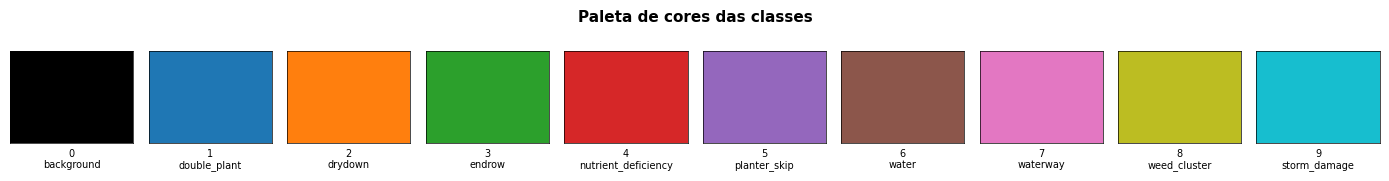

In [5]:
printColorPalette()

Aqui, se utilizou o cmap Reds, Greens e Blues. Essa imagem de RGB não foi eu quem coloquei essa mancha da mask sobre ela, ela veio assim.

## Inspeção de uma amostra

Visualiza uma amostra do split de treino — bandas de entrada, máscara de validade (*mask*), *boundary* e os rótulos por classe. A célula seguinte imprime os *shapes* de cada tensor.

PS.: Aqui, utilizou-se o cmap Reds, Greens e Blues. E a imagem RGB é originalmente assim, isto é, a mask representa uma área não válida na própria RGB, não se atribuiu a mask na própria imagem, ela é assim.

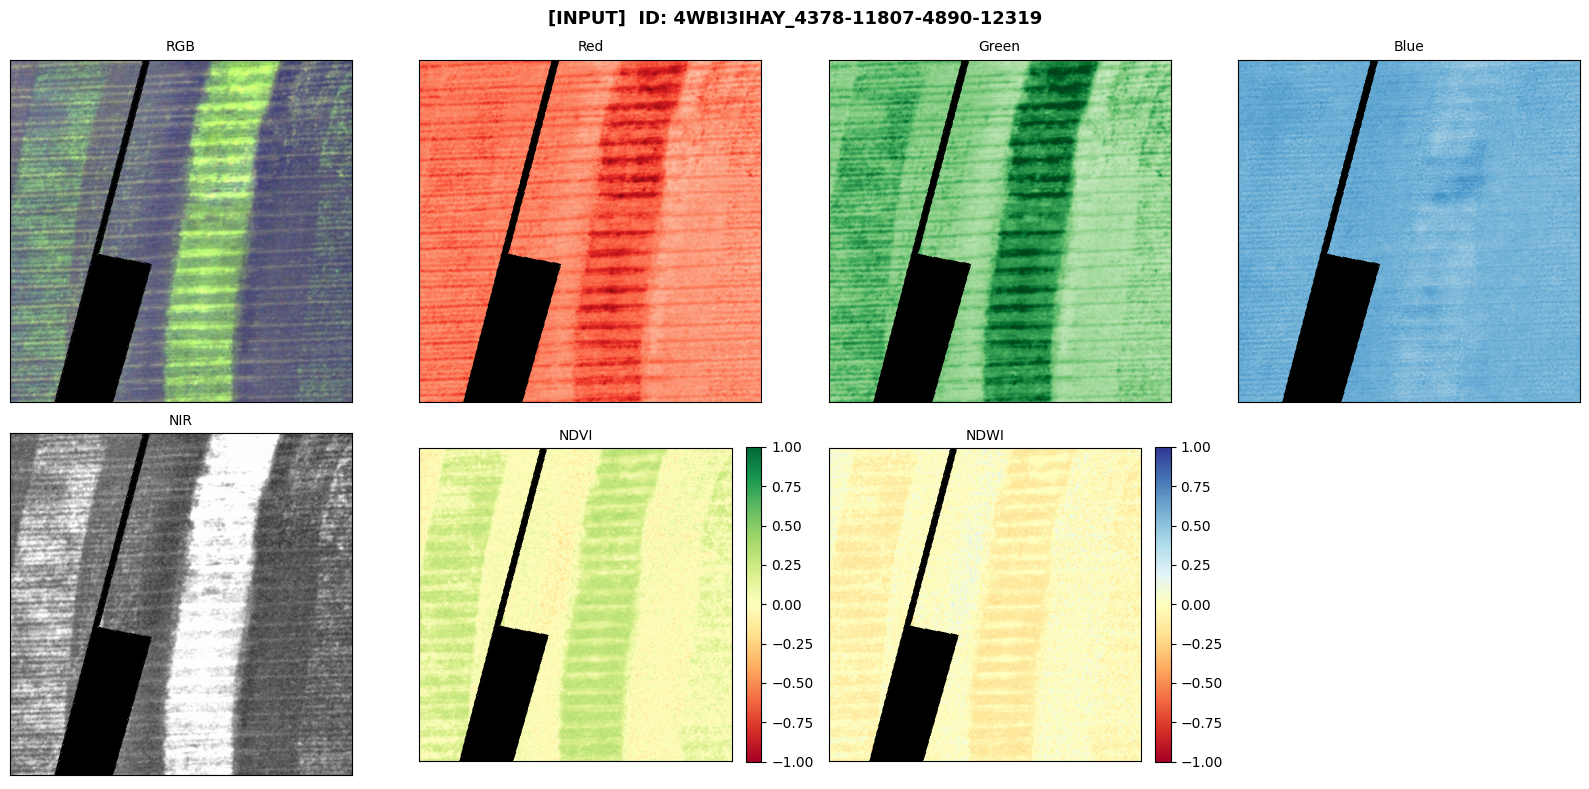

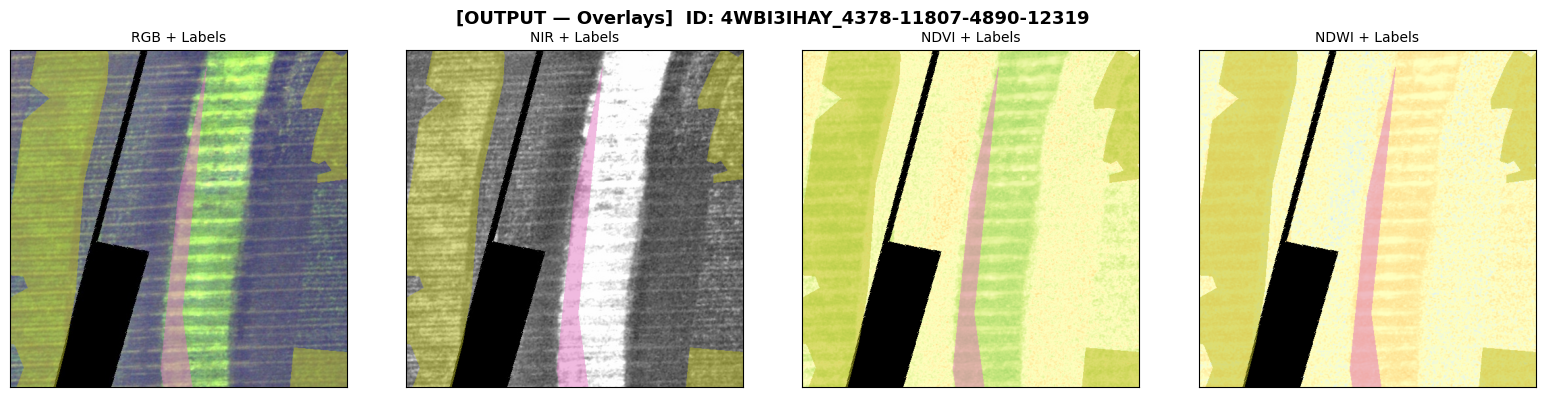

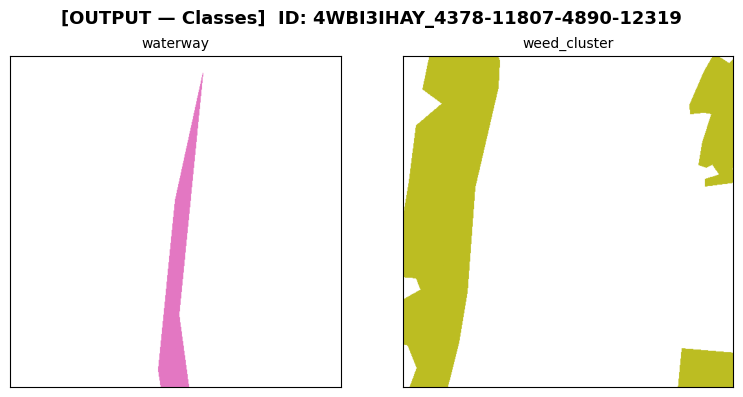

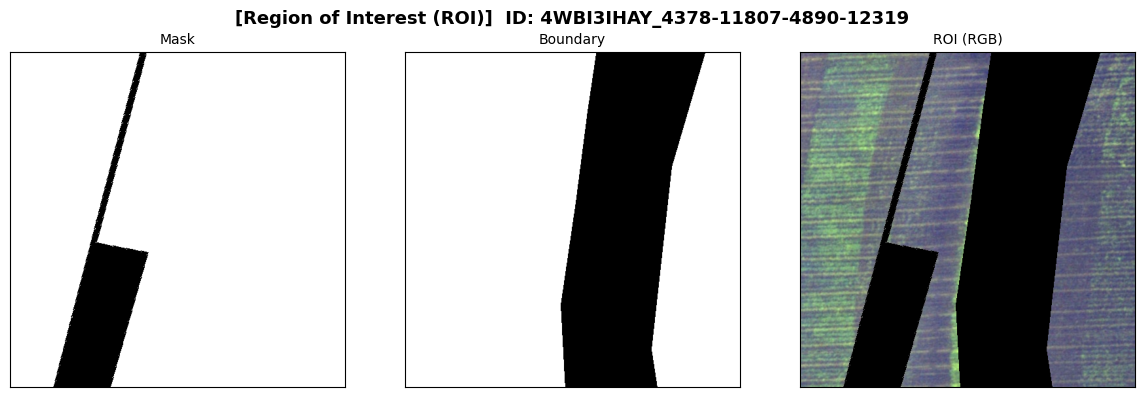

In [6]:
sample = train_dataset[45]
image = sample['image']
mask = sample['mask']
input_channels = sample['input_channels']
id = sample['id']
labels = sample['labels']
boundary = sample['boundary']

printInput(image=image, mask=mask, input_channels=input_channels, id=id)
printOutput(image=image, input_channels=input_channels, classes2eval=CLASSES2EVAL, labels=labels, mask=mask, id=id)
printContext(image=image, mask=mask, boundary=boundary, input_channels=input_channels, id=id)

In [7]:
print(f"Shape image: {sample['image'].shape}")
print(f"Shape mask: {sample['mask'].shape}")
print(f"Shape boundary: {sample['boundary'].shape}")
print(f"Shape labels: {sample['labels'].shape}")

Shape image: torch.Size([6, 512, 512])
Shape mask: torch.Size([512, 512])
Shape boundary: torch.Size([512, 512])
Shape labels: torch.Size([8, 512, 512])


In [8]:
# printSampleById("/home/visionary/Brendon/LeticiaRittner/Dataset/Agriculture-Vision-2021/train/images/rgb/4WBI3IHAY_4378-11807-4890-12319.jpg")

## Avaliação qualitativa — predições do modelo

Carrega o `best.pth` (canais lidos do `data_module`) e desenha a predição sobre o RGB, no estilo das figuras do paper. `test_model` aceita um `sample_id` específico ou sorteia uma amostra aleatória do split de **teste**.

> O checkpoint precisa casar com `INPUT_CHANNELS`

IoU por classe — ID 9WHPKBUJ9_2429-2263-2941-2775:
  drydown              IoU = 0.478
  mIoU (classes presentes) = 0.478


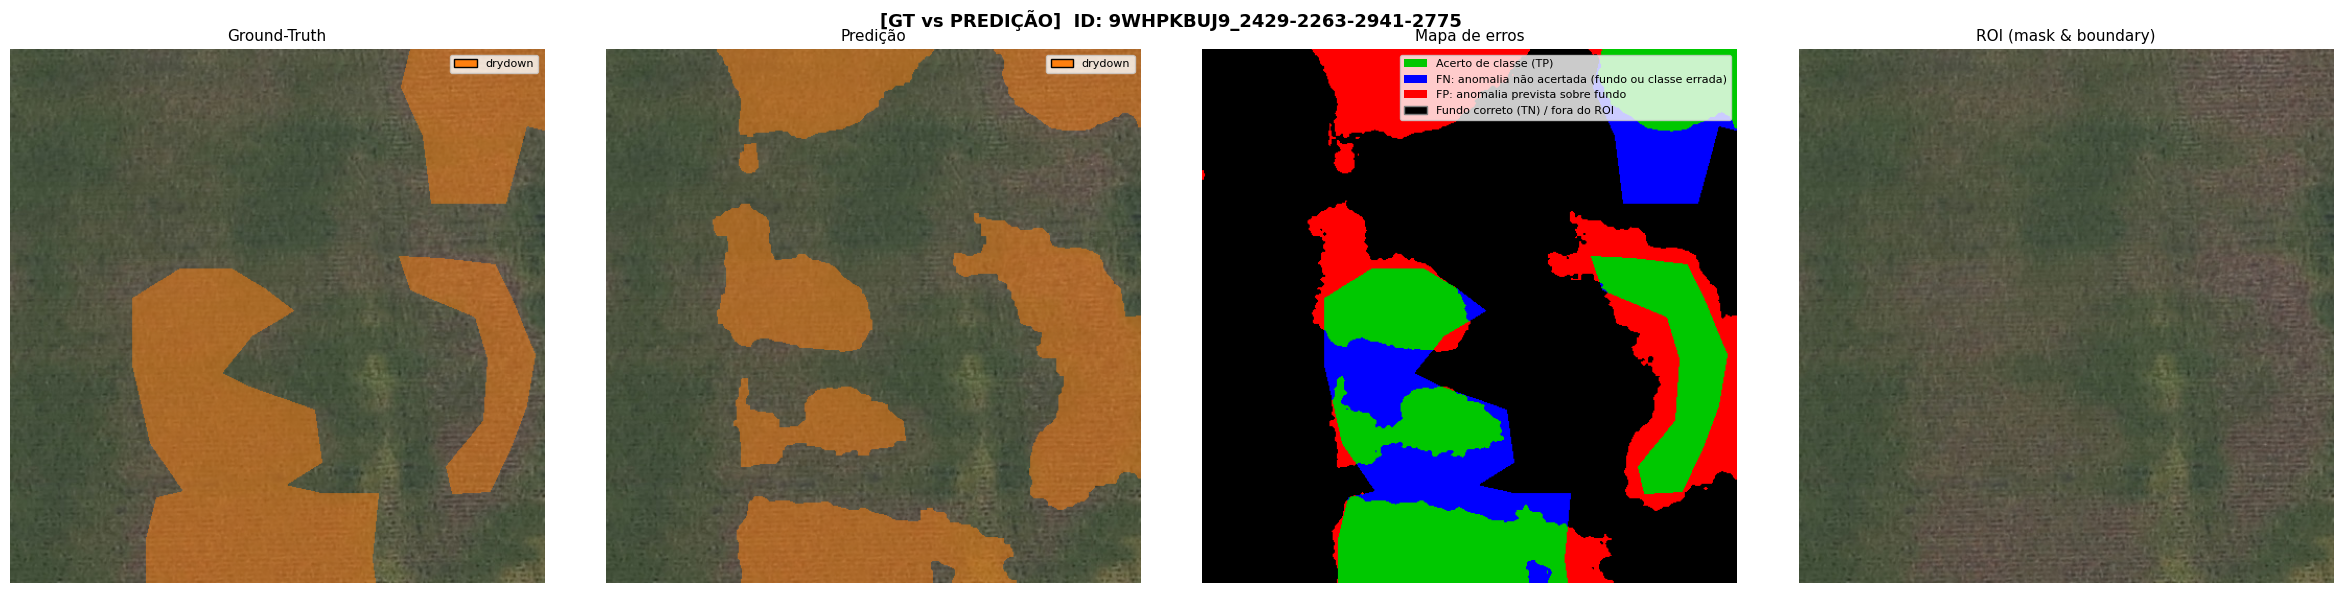

In [10]:
test_model(f"../experiments/checkpoints/{INPUT_CHANNELS}/best.pth", datamodule=data_module, threshold=0.5)

IoU por classe — ID WZ6EV6JEY_4417-8705-4929-9217:
  drydown              IoU = 0.423
  mIoU (classes presentes) = 0.423


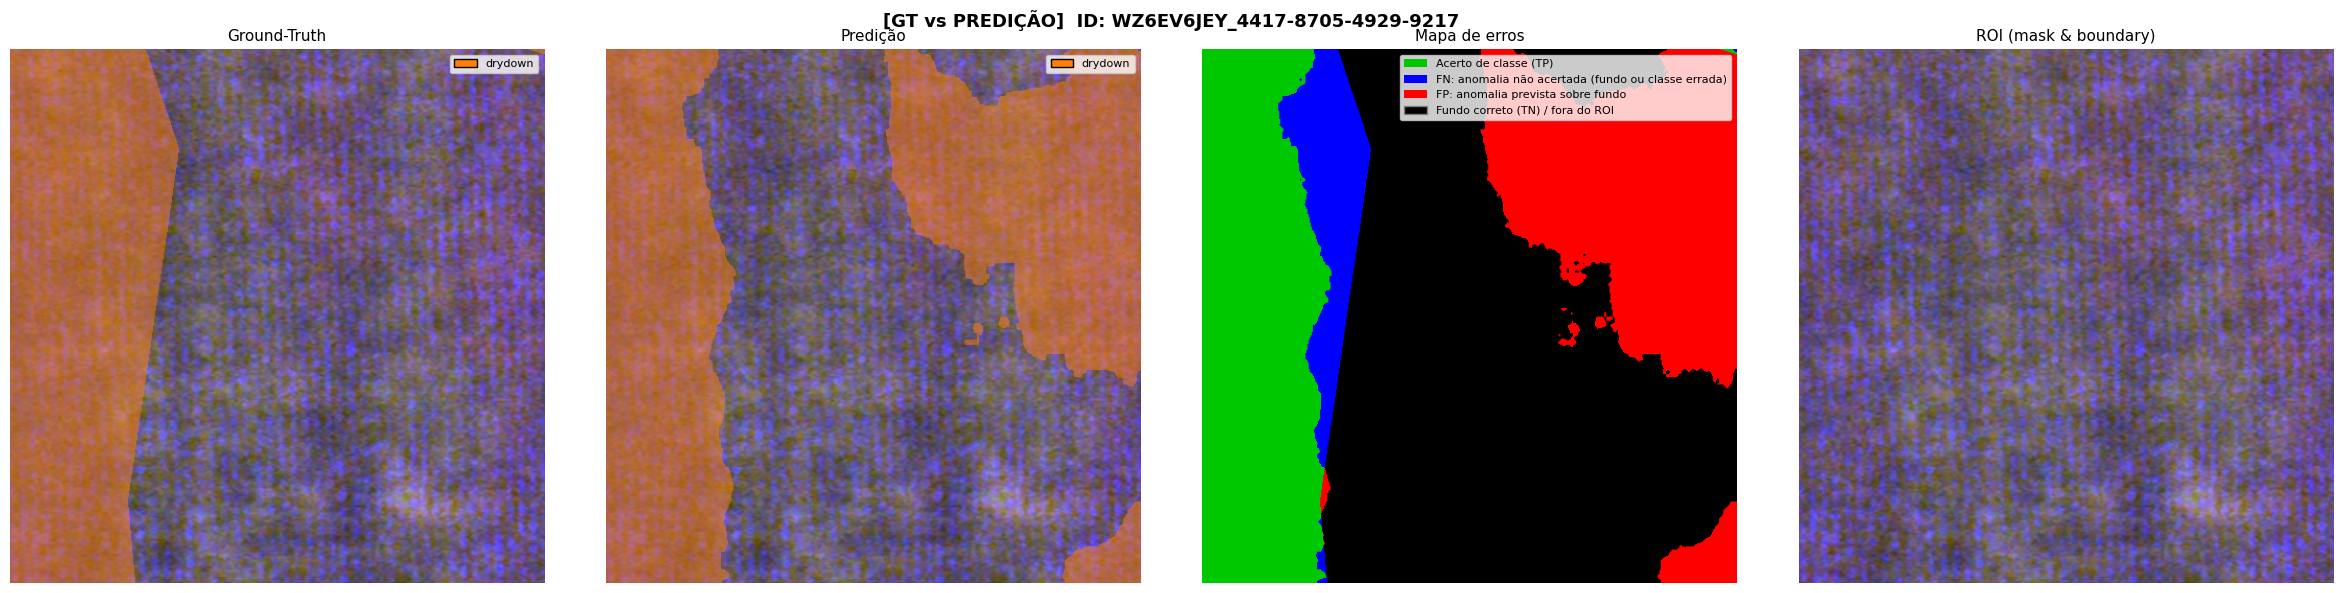

In [ ]:
test_model(f"../experiments/checkpoints/{INPUT_CHANNELS}/best.pth", sample_id="WZ6EV6JEY_4417-8705-4929-9217", datamodule=data_module, threshold=0.5)

IoU por classe — ID 8XHFF288I_12205-8025-12717-8537:
  drydown              IoU = 0.000
  water                IoU = 0.000
  weed_cluster         IoU = 0.000
  mIoU (classes presentes) = 0.000


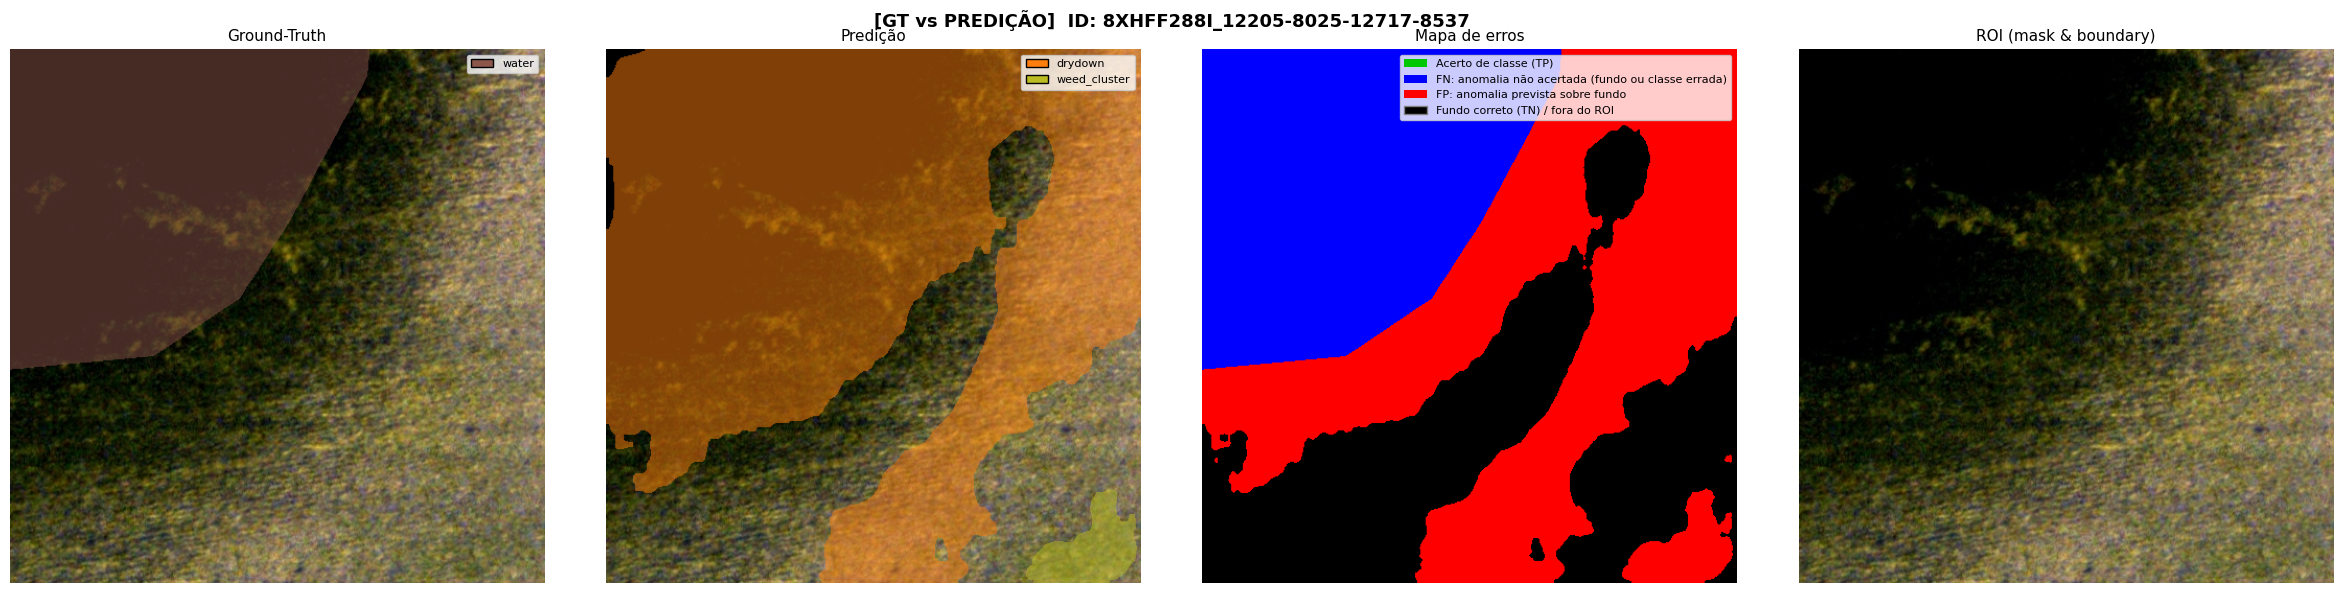

In [ ]:
test_model(f"../experiments/checkpoints/{INPUT_CHANNELS}/best.pth", datamodule=data_module, threshold=0.5)

IoU por classe — ID DT8Y6CZLV_4949-5236-5461-5748:
  drydown              IoU = 0.773
  weed_cluster         IoU = 0.000
  mIoU (classes presentes) = 0.386


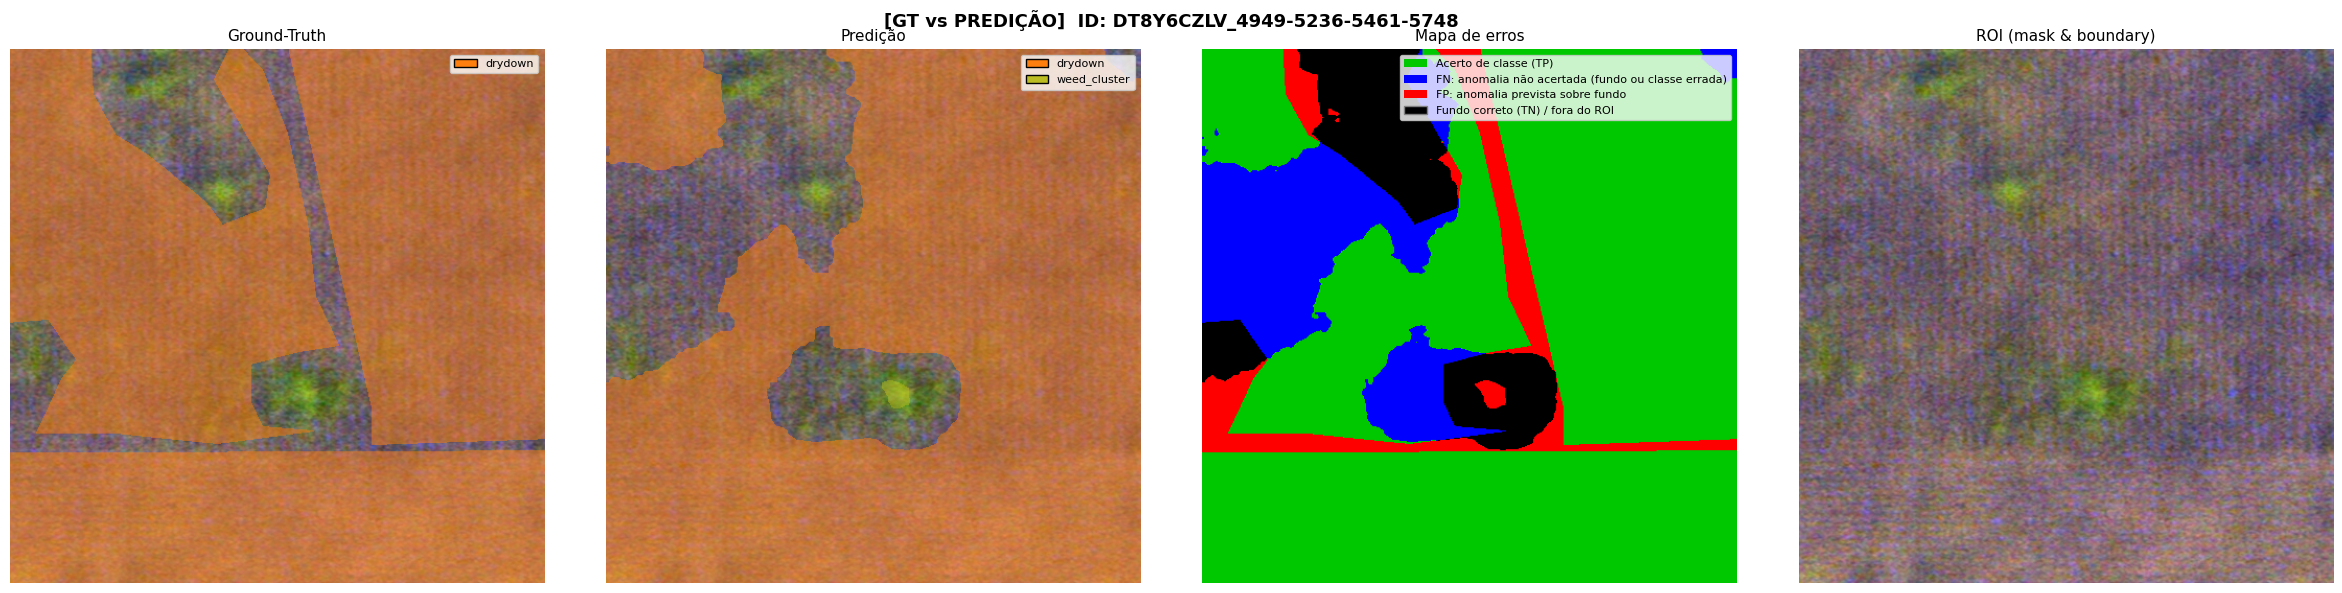

In [ ]:
test_model(f"../experiments/checkpoints/{INPUT_CHANNELS}/best.pth", sample_id="DT8Y6CZLV_4949-5236-5461-5748", datamodule=data_module, threshold=0.5)

IoU por classe — ID A2YGL9XDW_8308-1627-8820-2139:
  drydown              IoU = 0.539
  mIoU (classes presentes) = 0.539


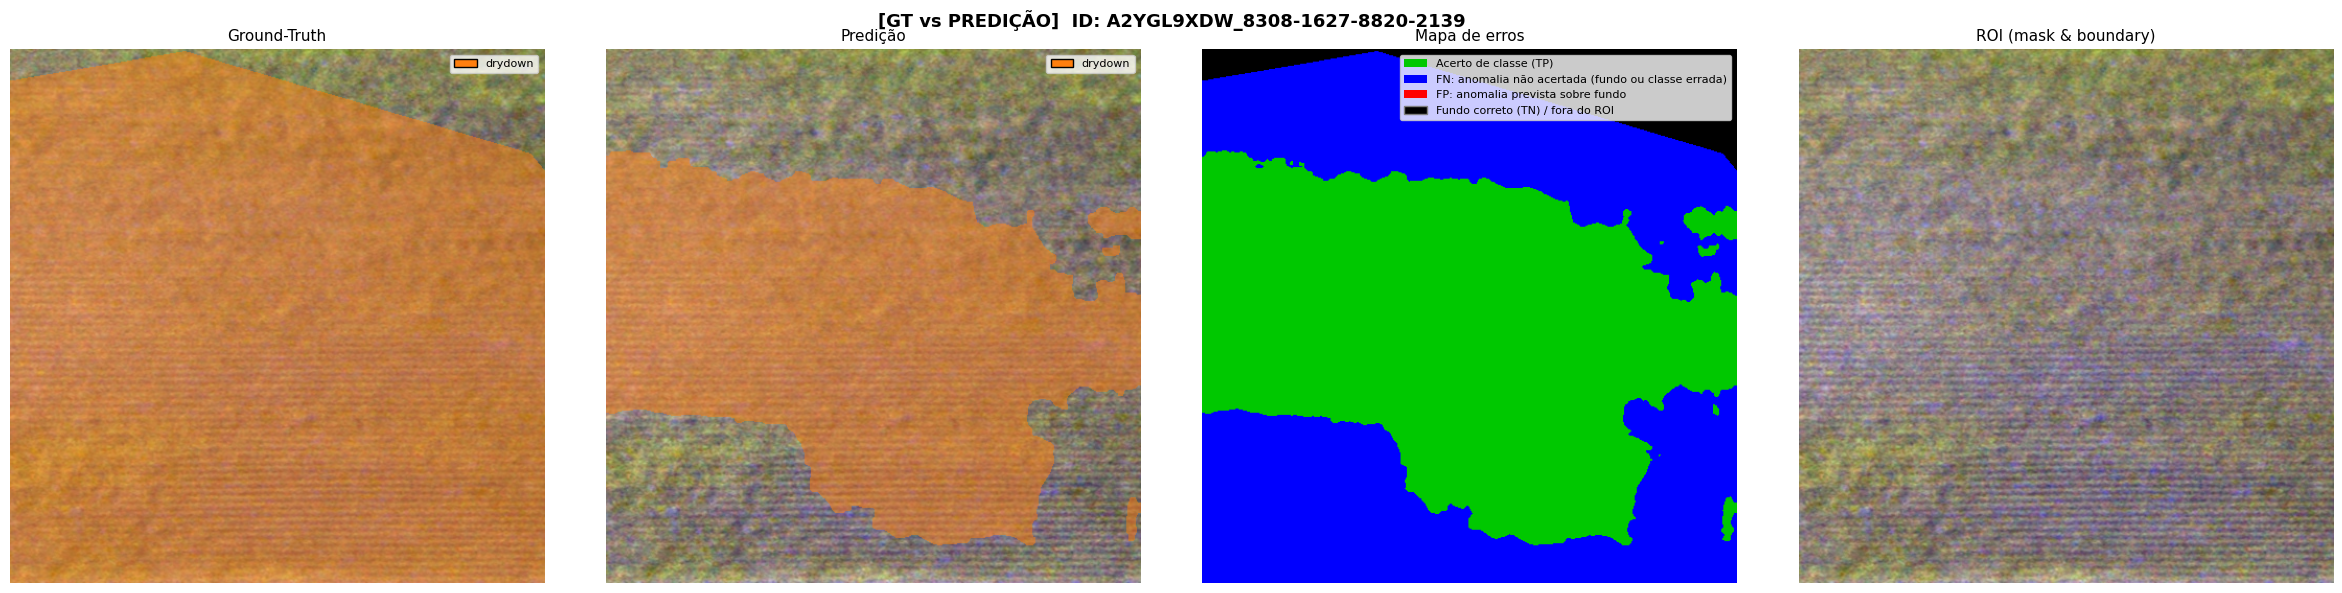

In [ ]:
test_model(f"../experiments/checkpoints/{INPUT_CHANNELS}/best.pth", sample_id="A2YGL9XDW_8308-1627-8820-2139", datamodule=data_module, threshold=0.5)

## Avaliação quantitativa — mIoU no teste

`evaluate_model` varre o split de teste inteiro e calcula a **mIoU modificada** + o IoU por classe (mesma métrica usada no treino, portanto comparável à validação). Com `save_path`, grava o resultado em JSON junto do checkpoint avaliado.

In [ ]:
miou, ious = evaluate_model(f"../experiments/checkpoints/{INPUT_CHANNELS}/best.pth",
                            datamodule=data_module,
                            save_path=f"../experiments/tensorboard/{INPUT_CHANNELS}/test_metricas.json",
                            usar_cache=True)

[TESTE] (cache: ../experiments/tensorboard/rgbnvw/test_metricas.json) mIoU modificada: 0.3738

  IoU[double_plant          ] = 0.2212
  IoU[drydown               ] = 0.5544
  IoU[endrow                ] = 0.1327
  IoU[nutrient_deficiency   ] = 0.3134
  IoU[planter_skip          ] = 0.2297
  IoU[water                 ] = 0.6565
  IoU[waterway              ] = 0.3045
  IoU[weed_cluster          ] = 0.2495
  IoU[background            ] = 0.7023
